# SFR Fly Mean-Reversion — League table

One row per (framework, variant). Sorted honestly: by net bp at **taker** costs,
with the grid median, the deflated Sharpe and the verdict alongside, so a row
that is only the best corner of a negative sweep is visible as such.

The verdict function is shared verbatim with the SR3 options lab
(`RVUtils/SFRRVLab/stats.py::verdict`):

* **ALIVE** — net positive at 2.5bp round trip, DSR probability above 0.5, a
  non-negative median config, and at least 10 trades.
* **SELECTION-ARTIFACT** — profitable at taker costs but failing deflation or
  the median-config test. The problem is the search, not the spread.
* **MARGINAL-maker-only** — a real edge at zero cost that the round trip eats.
* **DEAD** — no edge even gross.

Dollars assume **100 packages**: a 1/−2/1 SR3 butterfly is 4 contracts and
moves $25 per bp, so 100 packages is 400 contracts and **$2,500 per bp**.

In [1]:
import sys
from pathlib import Path

sys.path.append("../../")
sys.path.append(str(Path.cwd()))

import numpy as np
import pandas as pd

import matplotlib
if "ipykernel" not in sys.modules:
    matplotlib.use("Agg")
import matplotlib.pyplot as plt

from sfr_fly_meanrev_common import (
    DATA_DIR, LEAGUE_CSV, REGIME_CSV, SHADOW_CSV, SIGN_CSV,
)

pd.set_option("display.width", 250)
pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 200)

tbl = pd.read_csv(LEAGUE_CSV)
print(f"{len(tbl)} league rows across {tbl['framework'].nunique()} frameworks")

48 league rows across 24 frameworks


## 1. The table

In [2]:
cols = ["framework", "variant", "structure", "window", "n_trades", "hit_rate",
        "avg_net_bp", "total_gross_bp", "net_bp_maker", "net_bp_taker",
        "net_usd_taker", "sharpe", "nonoverlap_sharpe", "max_dd_bp",
        "avg_hold_days", "dsr_prob", "grid_median_net_bp", "verdict"]
cols = [c for c in cols if c in tbl.columns]
srt = tbl.sort_values("net_bp_taker", ascending=False)[cols]
print(srt.round(3).to_string(index=False))
srt.to_csv(DATA_DIR / "league_table_sorted.csv", index=False)

                                    framework       variant structure   window  n_trades  hit_rate  avg_net_bp  total_gross_bp  net_bp_maker  net_bp_taker  net_usd_taker  sharpe  nonoverlap_sharpe  max_dd_bp  avg_hold_days  dsr_prob  grid_median_net_bp               verdict
5b. Kalman dynamic hedge ratio (3m, liquid16)   best-config        3m liquid16         1     1.000      15.000           16.50         16.50         14.00        35000.0   9.543                NaN       0.00          4.000       NaN               0.000 DEAD (too few trades)
           2b. OU S-score (3m, front8, 2019+)   best-config        3m   front8        47     0.426       1.261          129.75        129.75         12.25        30625.0   0.630              0.235     -37.25         18.511     0.038             -53.875    SELECTION-ARTIFACT
                2c. OU S-score (6m, liquid16)   best-config        6m liquid16       140     0.379       1.036          355.00        355.00          5.00        12500.0   0.4

## 2. The table in one line

In [3]:
vc = tbl["verdict"].value_counts()
print(f"verdict counts: {vc.to_dict()}")
print(f"\nmedian DSR probability across the table : {tbl['dsr_prob'].median():.4f} "
      f"(threshold 0.5)")
print(f"rows with a POSITIVE grid median         : "
      f"{int((tbl['grid_median_net_bp'] > 0).sum())}/{len(tbl)}")
print(f"rows net positive at taker (2.5bp)       : "
      f"{int((tbl['net_bp_taker'] > 0).sum())}/{len(tbl)}")
print(f"rows net positive at maker (0.0bp)       : "
      f"{int((tbl['net_bp_maker'] > 0).sum())}/{len(tbl)}")
print(f"rows net positive GROSS                  : "
      f"{int((tbl['total_gross_bp'] > 0).sum())}/{len(tbl)}")
alive = tbl[tbl["verdict"] == "ALIVE"]
print(f"\nALIVE: {len(alive)}")
if len(alive):
    print(alive[cols].round(3).to_string(index=False))

verdict counts: {'MARGINAL-maker-only': 35, 'DEAD': 8, 'DEAD (too few trades)': 3, 'SELECTION-ARTIFACT': 2}

median DSR probability across the table : 0.0000 (threshold 0.5)
rows with a POSITIVE grid median         : 0/48
rows net positive at taker (2.5bp)       : 3/48
rows net positive at maker (0.0bp)       : 38/48
rows net positive GROSS                  : 38/48

ALIVE: 0


## 3. Best-config versus median-config

The single most informative column pair in the lab. If the best config is far
above the median config, the headline number is a property of the search.

In [4]:
if "variant" in tbl.columns:
    piv = tbl.pivot_table(index="framework", columns="variant",
                          values="net_bp_taker", aggfunc="first")
    for c in ("best-config", "median-config"):
        if c not in piv.columns:
            piv[c] = np.nan
    piv["gap"] = piv["best-config"] - piv["median-config"]
    print(piv.sort_values("best-config", ascending=False).round(2).to_string())

variant                                        best-config  best-gate  median-config  median-gate      gap
framework                                                                                                 
5b. Kalman dynamic hedge ratio (3m, liquid16)        14.00        NaN           0.00          NaN    14.00
2b. OU S-score (3m, front8, 2019+)                   12.25        NaN        -100.75          NaN   113.00
2c. OU S-score (6m, liquid16)                         5.00        NaN        -111.25          NaN   116.25
7b. Cross-sectional rank (3m, front8, 2019+)          0.00        NaN        -968.00          NaN   968.00
2. OU S-score (3m, liquid16)                        -14.50        NaN        -229.25          NaN   214.75
3b. Fitted EG spread signal, fly traded             -49.50        NaN        -325.00          NaN   275.50
4b. PCA residual, raw bp (no z)                     -50.00        NaN        -254.00          NaN   204.00
1b. Bollinger band-crossing (3m, liqu

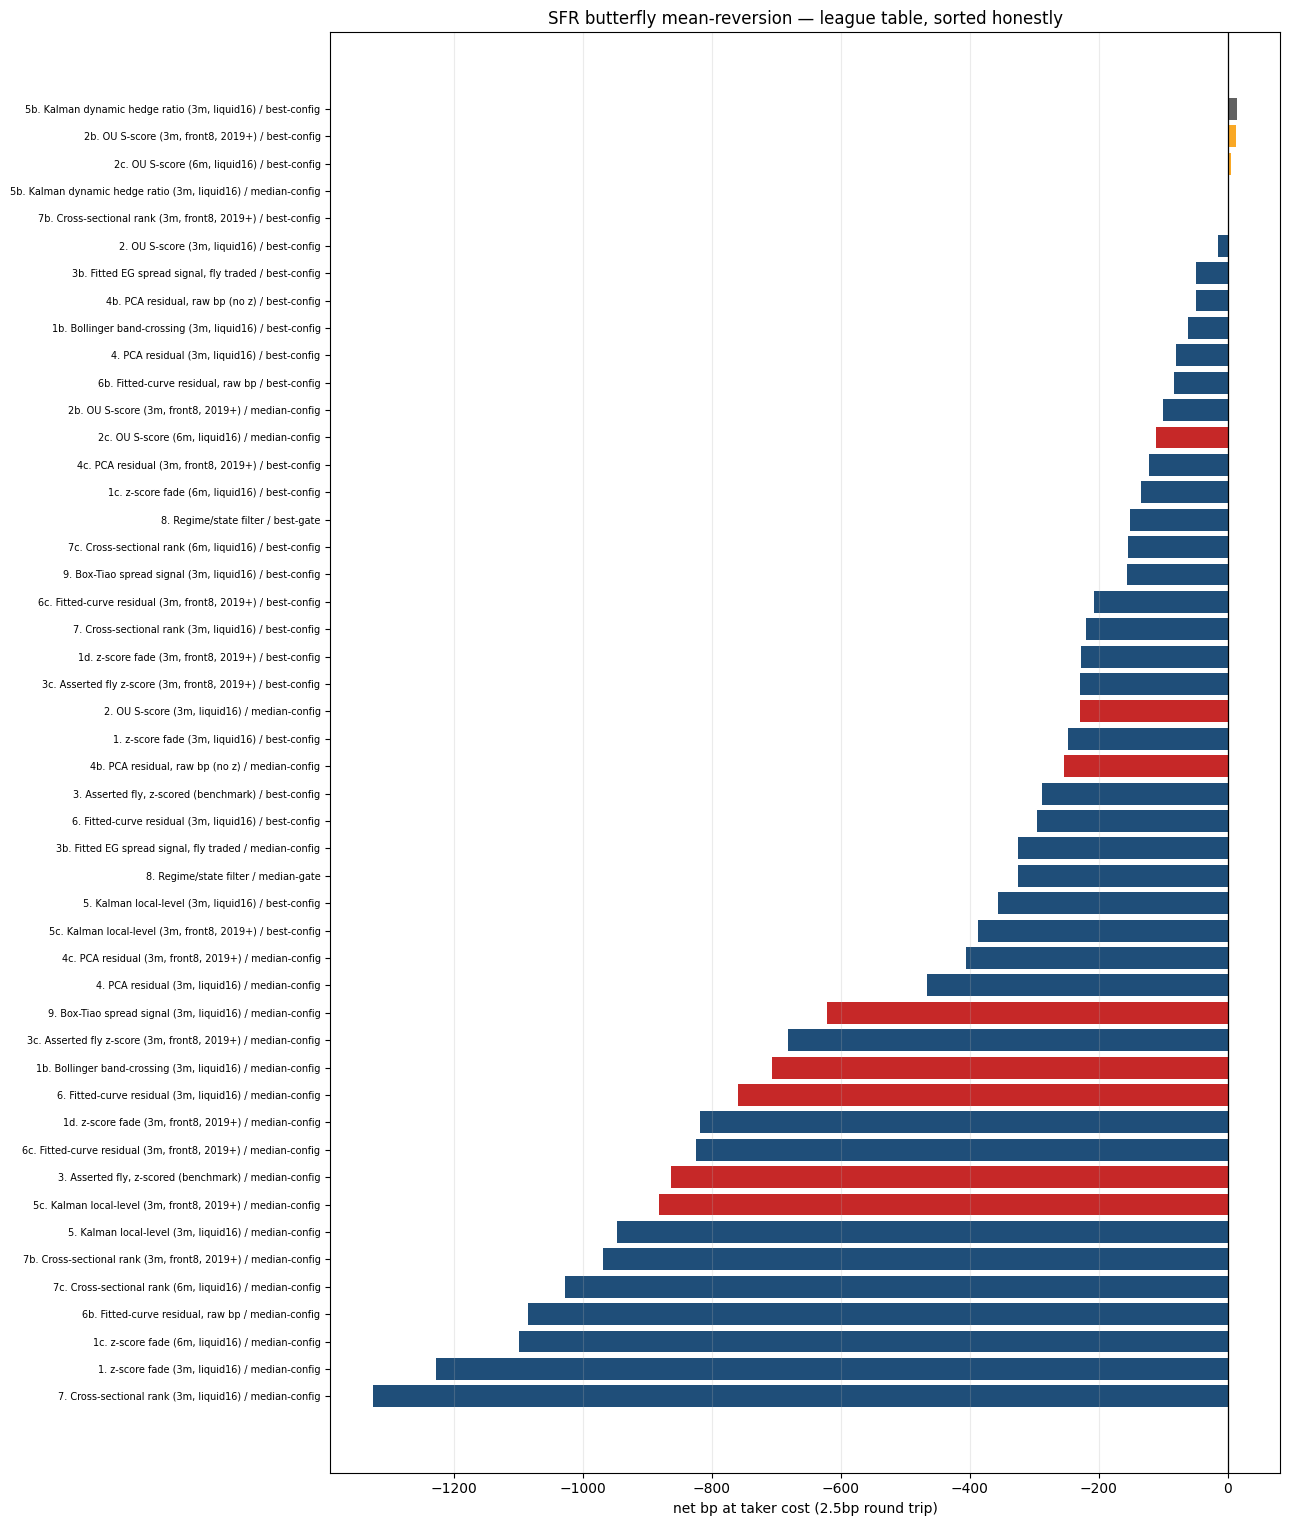

In [5]:
fig, ax = plt.subplots(figsize=(13, max(4, 0.32 * len(srt))))
colors = {"ALIVE": "#2e7d32", "SELECTION-ARTIFACT": "#f9a825",
          "MARGINAL-maker-only": "#1f4e79", "DEAD": "#c62828"}
lab_names = (srt["framework"] + " / " + srt["variant"]).to_numpy()
cvals = [colors.get(v, "#616161") for v in srt["verdict"]]
ax.barh(lab_names[::-1], srt["net_bp_taker"].to_numpy()[::-1],
        color=cvals[::-1])
ax.axvline(0, color="black", lw=0.9)
ax.set_xlabel("net bp at taker cost (2.5bp round trip)")
ax.set_title("SFR butterfly mean-reversion — league table, sorted honestly",
             fontsize=12)
ax.tick_params(axis="y", labelsize=7)
ax.grid(alpha=0.25, axis="x")
fig.tight_layout()
plt.show()

## 4. The cost curve is the whole story

Gross versus net at maker and taker, per framework.

                                               total_gross_bp  net_bp_maker  net_bp_taker
framework                                                                                
2c. OU S-score (6m, liquid16)                          355.00        355.00          5.00
1c. z-score fade (6m, liquid16)                        266.00        266.00       -134.00
6b. Fitted-curve residual, raw bp                      171.25        171.25        -83.75
6c. Fitted-curve residual (3m, front8, 2019+)          148.00        148.00       -207.00
3. Asserted fly, z-scored (benchmark)                  147.50        147.50       -287.50
6. Fitted-curve residual (3m, liquid16)                137.50        137.50       -295.00
2b. OU S-score (3m, front8, 2019+)                     129.75        129.75         12.25
7c. Cross-sectional rank (6m, liquid16)                113.25        113.25       -154.25
3c. Asserted fly z-score (3m, front8, 2019+)           111.25        111.25       -228.75
4c. PCA re

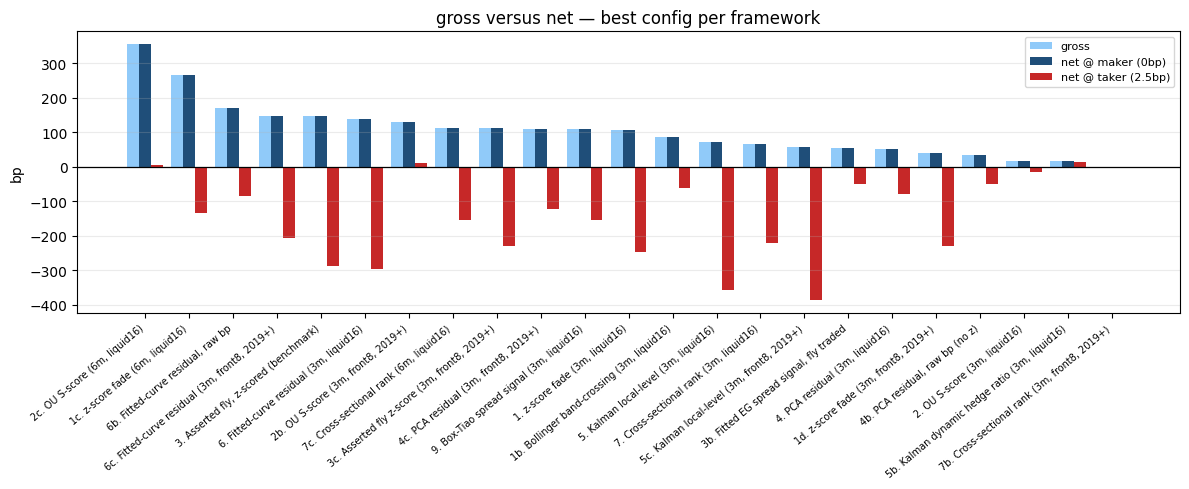

In [6]:
cc = tbl[["framework", "variant", "total_gross_bp", "net_bp_maker",
          "net_bp_taker"]].copy()
cc = cc[cc["variant"] == "best-config"].set_index("framework")
cc = cc.drop(columns="variant").sort_values("total_gross_bp", ascending=False)
print(cc.round(2).to_string())
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(cc))
ax.bar(x - 0.27, cc["total_gross_bp"], 0.27, label="gross", color="#90caf9")
ax.bar(x, cc["net_bp_maker"], 0.27, label="net @ maker (0bp)", color="#1f4e79")
ax.bar(x + 0.27, cc["net_bp_taker"], 0.27, label="net @ taker (2.5bp)",
       color="#c62828")
ax.axhline(0, color="black", lw=0.9)
ax.set_xticks(x)
ax.set_xticklabels(cc.index, rotation=40, ha="right", fontsize=7)
ax.set_ylabel("bp")
ax.set_title("gross versus net — best config per framework", fontsize=12)
ax.legend(fontsize=8)
ax.grid(alpha=0.25, axis="y")
fig.tight_layout()
plt.show()

## 5. Sign test — did mean reversion or momentum win?

In [7]:
if SIGN_CSV.exists():
    sg = pd.read_csv(SIGN_CSV)
    print(sg.round(3).to_string(index=False))
    if "winning_sign" in sg.columns:
        w = sg.drop_duplicates("framework")["winning_sign"].value_counts()
        print(f"\nwinning sign by framework: {w.to_dict()}")

                                    framework direction  n_configs  median_net_bp  pct_positive  best_net_bp  median_trades winning_sign
               1. z-score fade (3m, liquid16)      fade        192       -656.625         0.000      -106.00          466.5         fade
               1. z-score fade (3m, liquid16)  momentum        192       -746.125         0.000      -263.75          466.5         fade
   1b. Bollinger band-crossing (3m, liquid16)      fade         36       -349.125         0.000       -11.50          285.0         fade
   1b. Bollinger band-crossing (3m, liquid16)  momentum         36       -523.625         0.000      -155.00          285.0         fade
              1c. z-score fade (6m, liquid16)      fade        192       -653.375         0.005        26.00          391.0     momentum
              1c. z-score fade (6m, liquid16)  momentum        192       -515.125         0.000      -213.00          391.0     momentum
         1d. z-score fade (3m, front8, 20

## 6. Linear-shadow decomposition across frameworks

`fly = (belly - front) + (belly - back)`. A framework whose edge is matched or
beaten by the outright belly is a directional trade; by one of the two
belly-versus-wing spreads, a calendar trade.

In [8]:
if SHADOW_CSV.exists():
    sh = pd.read_csv(SHADOW_CSV)
    piv = sh.pivot_table(index="framework", columns="instrument",
                         values="total_net_bp", aggfunc="first")
    order = [c for c in ["fly", "belly", "belly_vs_front", "belly_vs_back"]
             if c in piv.columns]
    piv = piv[order]
    piv["best_shadow"] = piv[[c for c in order if c != "fly"]].max(axis=1)
    piv["fly_beats_shadows"] = piv["fly"] > piv["best_shadow"]
    print(piv.round(2).to_string())
    print(f"\nframeworks where the fly beats every linear shadow: "
          f"{int(piv['fly_beats_shadows'].sum())}/{len(piv)}")

instrument                                       fly  belly  belly_vs_front  belly_vs_back  best_shadow  fly_beats_shadows
framework                                                                                                                 
1. z-score fade (3m, liquid16)                -106.0  389.5          -184.0            7.5        389.5              False
1b. Bollinger band-crossing (3m, liquid16)      -2.5  162.5            11.5          -43.5        162.5              False
1c. z-score fade (6m, liquid16)                 26.0  695.0          -178.0          124.0        695.0              False
1d. z-score fade (3m, front8, 2019+)          -121.0 -675.0          -235.0           60.5         60.5              False
2. OU S-score (3m, liquid16)                    -1.5  135.5            58.5          -66.5        135.5              False
2b. OU S-score (3m, front8, 2019+)              59.2  411.5            73.8          -38.0        411.5              False
2c. OU S-score (

## 7. Regime splits

One parameter set across ZIRP, a hiking cycle, a plateau and a cutting cycle.

In [9]:
if REGIME_CSV.exists():
    rg = pd.read_csv(REGIME_CSV)
    piv = rg.pivot_table(index="framework", columns="regime",
                         values="total_net_bp", aggfunc="first")
    order = [c for c in ["ZIRP", "HIKING", "PLATEAU", "CUTTING"] if c in piv.columns]
    piv = piv[order]
    piv["n_regimes_positive"] = (piv[order] > 0).sum(axis=1)
    print(piv.round(2).to_string())
    print("\ntrade counts by regime:")
    print(rg.pivot_table(index="framework", columns="regime", values="n_trades",
                         aggfunc="first").reindex(columns=order).to_string())
    print(f"\nframework-regime cells positive: "
          f"{int((rg['total_net_bp'] > 0).sum())}/{len(rg)}")

regime                                           ZIRP  HIKING  PLATEAU  CUTTING  n_regimes_positive
framework                                                                                          
1. z-score fade (3m, liquid16)                   0.00   28.25    -7.25  -127.00                   1
1b. Bollinger band-crossing (3m, liquid16)      -1.50   35.00   -17.00   -19.00                   1
1c. z-score fade (6m, liquid16)                 -3.00   88.75    48.75  -108.50                   2
1d. z-score fade (3m, front8, 2019+)          -107.50   36.75   -10.25   -40.00                   1
2. OU S-score (3m, liquid16)                     0.00    0.00     4.50    -6.00                   1
2b. OU S-score (3m, front8, 2019+)               2.50   87.00    -6.50   -23.75                   2
2c. OU S-score (6m, liquid16)                    0.00  120.75    45.50   -21.25                   2
3. Asserted fly, z-scored (benchmark)            3.00   36.50   -49.50  -103.50                   2


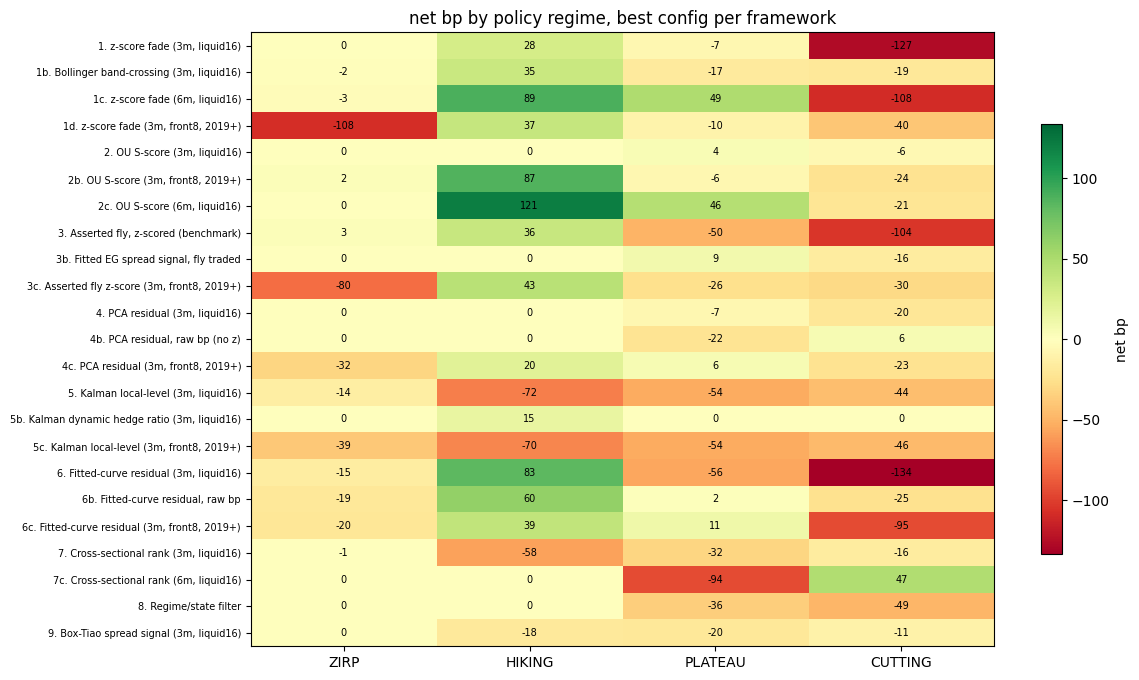

In [10]:
if REGIME_CSV.exists() and len(order):
    fig, ax = plt.subplots(figsize=(12, max(4, 0.3 * len(piv))))
    im = ax.imshow(piv[order].to_numpy(dtype=float), aspect="auto", cmap="RdYlGn",
                   vmin=-np.nanmax(np.abs(piv[order].to_numpy(dtype=float))),
                   vmax=np.nanmax(np.abs(piv[order].to_numpy(dtype=float))))
    ax.set_xticks(range(len(order)))
    ax.set_xticklabels(order)
    ax.set_yticks(range(len(piv)))
    ax.set_yticklabels(piv.index, fontsize=7)
    for i in range(len(piv)):
        for j, c in enumerate(order):
            v = piv.iloc[i][c]
            if np.isfinite(v):
                ax.text(j, i, f"{v:.0f}", ha="center", va="center", fontsize=7)
    ax.set_title("net bp by policy regime, best config per framework", fontsize=12)
    fig.colorbar(im, ax=ax, shrink=0.7, label="net bp")
    fig.tight_layout()
    plt.show()